# Weather forecasting with PySpark


## Define some global constants

In [ ]:
!sudo apt-get update

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [110 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [119 kB]
Hit:6 https://ppa.launchpadcontent.net/c2d4u.team/c2d4u4.0+/ubuntu jammy InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [2,118 kB]
Fetched 2,351 kB in 2s (1,336 kB/s)
Reading package lists... Done


In [ ]:
#Installing  JDK
#Install JRE
!sudo apt install default-jdk

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  default-jdk-headless default-jre default-jre-headless fonts-dejavu-core
  fonts-dejavu-extra libatk-wrapper-java libatk-wrapper-java-jni libfontenc1
  libice-dev libsm-dev libxkbfile1 libxt-dev libxtst6 libxxf86dga1
  openjdk-11-jdk openjdk-11-jre x11-utils
Suggested packages:
  libice-doc libsm-doc libxt-doc openjdk-11-demo openjdk-11-source visualvm
  mesa-utils
The following NEW packages will be installed:
  default-jdk default-jdk-headless default-jre default-jre-headless
  fonts-dejavu-core fonts-dejavu-extra libatk-wrapper-java
  libatk-wrapper-java-jni libfontenc1 libice-dev libsm-dev libxkbfile1
  libxt-dev libxtst6 libxxf86dga1 openjdk-11-jdk openjdk-11-jre x11-utils
0 upgraded, 18 newly installed, 0 to remove and 45 not upgraded.
Need to get 5,526 kB of archives.
After this operation, 15.8 MB of additional disk space will be u

In [ ]:
#Showing Java version
!java -version

openjdk version "11.0.22" 2024-01-16
OpenJDK Runtime Environment (build 11.0.22+7-post-Ubuntu-0ubuntu222.04.1)
OpenJDK 64-Bit Server VM (build 11.0.22+7-post-Ubuntu-0ubuntu222.04.1, mixed mode, sharing)


In [ ]:
#Download Apache Spark files
!wget https://archive.apache.org/dist/spark/spark-3.0.3/spark-3.0.3-bin-hadoop2.7.tgz

#Extracting spark files
!tar xvf spark-3.0.3-bin-hadoop2.7.tgz

--2024-05-20 01:00:01--  https://archive.apache.org/dist/spark/spark-3.0.3/spark-3.0.3-bin-hadoop2.7.tgz
Resolving archive.apache.org (archive.apache.org)... 65.108.204.189, 2a01:4f9:1a:a084::2
Connecting to archive.apache.org (archive.apache.org)|65.108.204.189|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 220400553 (210M) [application/x-gzip]
Saving to: ‘spark-3.0.3-bin-hadoop2.7.tgz’

spark-3.0.3-bin-had 100%[===================>] 210.19M  25.1MB/s    in 15s     

2024-05-20 01:00:17 (13.6 MB/s) - ‘spark-3.0.3-bin-hadoop2.7.tgz’ saved [220400553/220400553]

spark-3.0.3-bin-hadoop2.7/
spark-3.0.3-bin-hadoop2.7/NOTICE
spark-3.0.3-bin-hadoop2.7/kubernetes/
spark-3.0.3-bin-hadoop2.7/kubernetes/tests/
spark-3.0.3-bin-hadoop2.7/kubernetes/tests/worker_memory_check.py
spark-3.0.3-bin-hadoop2.7/kubernetes/tests/py_container_checks.py
spark-3.0.3-bin-hadoop2.7/kubernetes/tests/pyfiles.py
spark-3.0.3-bin-hadoop2.7/kubernetes/dockerfiles/
spark-3.0.3-bin-hadoop2.7/k

In [ ]:
#Installing findspark and pyspark
!pip install findspark
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.1-py2.py3-none-any.whl size=317488491 sha256=3d1b266cdd346ce909fd29ef233bbce8d7989960abc8e4ccdce702c5e3238450
  Stored in directory: /root/.cache/pip/wheels/80/1d/60/2c256ed38dddce2fdd93be545214a63e02fbd8d74fb0b7f3a6
Successfully built pyspark


In [ ]:
pip install databricks-cli

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 3.5 MB/s eta 0:00:00


In [ ]:
import os

In [ ]:
#We then run a local SparkSession
import findspark
findspark.init()
from pyspark.sql import SparkSession

#We then created a SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()

In [ ]:
#Checking if Pyspark shell is working
!pyspark

Python 3.10.12 (main, Nov 20 2023, 15:14:05) [GCC 11.4.0] on linux
Type "help", "copyright", "credits" or "license" for more information.
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/05/20 01:03:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
24/05/20 01:03:11 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
Welcome to
      ____              __
     / __/__  ___ _____/ /__
    _\ \/ _ \/ _ `/ __/  '_/
   /__ / .__/\_,_/_/ /_/\_\   version 3.5.1
      /_/

Using Python version 3.10.12 (main, Nov 20 2023 15:14:05)
Spark context Web UI available at http://28e2a37e8bf4:4041
Spark context available as 'sc' (master = local[*], app id = local-1716166991913).
SparkSession available as 'spark'.
>>> exit ()


## Import PySpark packages and other dependencies

In [ ]:
import pyspark
import numpy as np
import matplotlib.pyplot as plt
import pyspark.pandas as ps

from pyspark import SparkContext, SparkConf

from pyspark.sql import *
from pyspark.sql.types import *
from pyspark.sql.functions import *

from pyspark.ml.pipeline import PipelineModel
from pyspark.ml.tuning import CrossValidatorModel

from typing import *

/usr/local/lib/python3.10/dist-packages/pyspark/pandas/__init__.py:50: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


## Dataset initialization

In [ ]:
!wget --no-verbose https://github.com/Lucifer7779/Weather_forcasting/raw/main/historical-hourly-weather-dataset.zip -O /tmp/dataset.zip
!unzip -u /tmp/dataset.zip -d /tmp/dataset


2024-05-20 01:03:31 URL:https://raw.githubusercontent.com/Lucifer7779/Weather_forcasting/main/historical-hourly-weather-dataset.zip [12655281/12655281] -> "/tmp/dataset.zip" [1]
Archive:  /tmp/dataset.zip
   creating: /tmp/dataset/aggregated_sampled_weather_measurements.csv/
  inflating: /tmp/dataset/aggregated_sampled_weather_measurements.csv/._committed_7616641238230246128.crc  
  inflating: /tmp/dataset/aggregated_sampled_weather_measurements.csv/.part-00000-tid-5785058191842647654-99694b27-5637-4d82-97fd-79413e3b2b1a-5515-1-c000.csv.crc  
  inflating: /tmp/dataset/aggregated_sampled_weather_measurements.csv/.part-00006-tid-5785058191842647654-99694b27-5637-4d82-97fd-79413e3b2b1a-5521-1-c000.csv.crc  
  inflating: /tmp/dataset/aggregated_sampled_weather_measurements.csv/.part-00002-tid-5785058191842647654-99694b27-5637-4d82-97fd-79413e3b2b1a-5517-1-c000.csv.crc  
  inflating: /tmp/dataset/aggregated_sampled_weather_measurements.csv/.part-00004-tid-5785058191842647654-99694b27-5637-4

Move the dataset


In [ ]:
import os
import urllib.request
import zipfile

# Define paths
zip_url = 'https://github.com/Lucifer7779/Weather_forcasting/raw/main/historical-hourly-weather-dataset.zip'
zip_path = '/tmp/dataset.zip'
extract_path = '/tmp/dataset'
DATASET_PATH = '/historical-hourly-weather-dataset/'

# Step 1: Download the ZIP file
urllib.request.urlretrieve(zip_url, zip_path)

# Step 2: Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Step 3: Move files to the target directory
if not os.path.exists(DATASET_PATH):
    os.makedirs(DATASET_PATH)

for root, dirs, files in os.walk(extract_path):
    for file in files:
        os.rename(os.path.join(root, file), os.path.join(DATASET_PATH, file))

print("Files have been moved successfully.")




Files have been moved successfully.




```
# This is formatted as code
```

### Load dataset

In [ ]:
weather_conditions_df = ps.read_csv(f'{DATASET_PATH}weather_description.csv')
humidity_df = ps.read_csv(f'{DATASET_PATH}humidity.csv')
pressure_df = ps.read_csv(f'{DATASET_PATH}pressure.csv')
temperature_df = ps.read_csv(f'{DATASET_PATH}temperature.csv')
city_attributes_df = ps.read_csv(f'{DATASET_PATH}city_attributes.csv')
wind_direction_df = ps.read_csv(f'{DATASET_PATH}wind_direction.csv')
wind_speed_df = ps.read_csv(f'{DATASET_PATH}wind_speed.csv')

/usr/local/lib/python3.10/dist-packages/pyspark/pandas/utils.py:1016: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `read_csv`, the default index is attached which can cause additional overhead.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


### Dataset shape and schema



In [93]:
def print_dataframe_shape(dataframe: Union[DataFrame, ps.DataFrame]) -> None:

    if isinstance(dataframe, ps.DataFrame): dataframe = dataframe.to_spark()

    rows_count = dataframe.count()
    columns_count = len(dataframe.columns)

    print(f'The shape of the dataset is {rows_count} rows by {columns_count} columns', end='\n\n')

#### `city_attributes.csv`

In [ ]:
print_dataframe_shape(city_attributes_df)

/usr/local/lib/python3.10/dist-packages/pyspark/pandas/utils.py:1016: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `to_spark`, the existing index is lost when converting to Spark DataFrame.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


The shape of the dataset is 36 rows by 4 columns



In [ ]:
city_attributes_df.spark.print_schema()

root
 |-- City: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)



In [ ]:
city_attributes_df.head(5)

,City,Country,Latitude,Longitude
0,Vancouver,Canada,49.249660,-123.119339
1,Portland,United States,45.523449,-122.676208
2,San Francisco,United States,37.774929,-122.419418
3,Seattle,United States,47.606209,-122.332069
4,Los Angeles,United States,34.052231,-118.243683


#### `weather_description.csv`

In [ ]:
print_dataframe_shape(weather_conditions_df)

/usr/local/lib/python3.10/dist-packages/pyspark/pandas/utils.py:1016: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `to_spark`, the existing index is lost when converting to Spark DataFrame.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


The shape of the dataset is 45253 rows by 37 columns



In [ ]:
weather_conditions_df.spark.print_schema()

root
 |-- datetime: timestamp (nullable = true)
 |-- Vancouver: string (nullable = true)
 |-- Portland: string (nullable = true)
 |-- San Francisco: string (nullable = true)
 |-- Seattle: string (nullable = true)
 |-- Los Angeles: string (nullable = true)
 |-- San Diego: string (nullable = true)
 |-- Las Vegas: string (nullable = true)
 |-- Phoenix: string (nullable = true)
 |-- Albuquerque: string (nullable = true)
 |-- Denver: string (nullable = true)
 |-- San Antonio: string (nullable = true)
 |-- Dallas: string (nullable = true)
 |-- Houston: string (nullable = true)
 |-- Kansas City: string (nullable = true)
 |-- Minneapolis: string (nullable = true)
 |-- Saint Louis: string (nullable = true)
 |-- Chicago: string (nullable = true)
 |-- Nashville: string (nullable = true)
 |-- Indianapolis: string (nullable = true)
 |-- Atlanta: string (nullable = true)
 |-- Detroit: string (nullable = true)
 |-- Jacksonville: string (nullable = true)
 |-- Charlotte: string (nullable = true)
 |-- M

In [ ]:
weather_conditions_df[weather_conditions_df.columns[:5]].head(5)

,datetime,Vancouver,Portland,San Francisco,Seattle
0,2012-10-01 12:00:00,None,None,None,None
1,2012-10-01 13:00:00,mist,scattered clouds,light rain,sky is clear
2,2012-10-01 14:00:00,broken clouds,scattered clouds,sky is clear,sky is clear
3,2012-10-01 15:00:00,broken clouds,scattered clouds,sky is clear,sky is clear
4,2012-10-01 16:00:00,broken clouds,scattered clouds,sky is clear,sky is clear


## Dataset preprocessing

### Columns constants

Here we are defining some constants regarding the dataset columns which we are going to use throughout this notebook.

In [ ]:
DATETIME_COL = 'datetime'
HUMIDITY_COL = 'humidity'
PRESSURE_COL = 'pressure'
TEMPERATURE_COL = 'temperature'
WIND_DIRECTION_COL = 'wind_direction'
WIND_SPEED_COL = 'wind_speed'
LATITUDE_COL = 'latitude'
LONGITUDE_COL = 'longitude'
CITY_COL = 'city'
COUNTRY_COL = 'country'
WEATHER_CONDITION_COL = 'weather_condition'

### Create a single `DataFrame` that includes all data from the others



In [ ]:
def filter_dataframe_by_city_column(dataframe: ps.DataFrame,
                                    city_name: str,
                                    new_column_name: str) -> DataFrame:
    '''
    Args:
        - dataframe: a `DataFrame` with a datetime column and n cities columns,
                     where the records are the related hourly measurements
        - city_name: city name between the ones in the dataframe
        - new_column_name: name to replace the city name

    Returns:
        a new `DataFrame` with:
            - the datetime column
            - a single column of measurements related to the `city_name`
              and renamed as `new_column_name`
    '''
    return dataframe.to_spark() \
        .withColumn(new_column_name, col(city_name)) \
        .select([DATETIME_COL, new_column_name])

In [ ]:
def join_dataframes(dataframes: List[DataFrame], column_name: str) -> DataFrame:
    '''
    Args:
        - dataframse: a list of `DataFrame` to be joined
        - column_name: the column over which the records should be joined

    Returns:
        a new dataframes resulting from the join of all the dataframes
        over the `column_name` column
    '''
    joined_df = dataframes[0]

    for dataframe in dataframes[1:]:
        joined_df = joined_df.join(dataframe, [column_name])

    return joined_df

In [ ]:
weather_measurements_df = None

# Iterate over all the records in the cities `DataFrame`
for index, row in city_attributes_df.iterrows():

    city = row.City
    country = row.Country
    latitude = row.Latitude
    longitude = row.Longitude

    # Compute a list of `DataFrame`, one for each type of measurement in the city
    dataframes = [
        filter_dataframe_by_city_column(humidity_df, city, HUMIDITY_COL),
        filter_dataframe_by_city_column(pressure_df, city, PRESSURE_COL),
        filter_dataframe_by_city_column(temperature_df, city, TEMPERATURE_COL),
        filter_dataframe_by_city_column(wind_direction_df, city, WIND_DIRECTION_COL),
        filter_dataframe_by_city_column(wind_speed_df, city, WIND_SPEED_COL),
        filter_dataframe_by_city_column(weather_conditions_df, city, WEATHER_CONDITION_COL)
    ]

    # Compute a `DataFrame` that includes all the data about the measurements in the city
    joined_df = join_dataframes(dataframes, DATETIME_COL) \
        .withColumn(CITY_COL, lit(city)) \
        .withColumn(COUNTRY_COL, lit(country)) \
        .withColumn(LATITUDE_COL, lit(latitude)) \
        .withColumn(LONGITUDE_COL, lit(longitude))

    # Union the `DataFrame` with the ones computed in the previous iterations
    weather_measurements_df = weather_measurements_df.union(joined_df) if weather_measurements_df is not None else joined_df

/usr/local/lib/python3.10/dist-packages/pyspark/pandas/utils.py:1016: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `to_spark`, the existing index is lost when converting to Spark DataFrame.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


#### Check the shape of the newly created dataset

In [ ]:
print_dataframe_shape(weather_measurements_df)

The shape of the dataset is 1629108 rows by 11 columns



#### Print out the new schema

In [ ]:
weather_measurements_df.printSchema()

root
 |-- datetime: timestamp (nullable = true)
 |-- humidity: double (nullable = true)
 |-- pressure: double (nullable = true)
 |-- temperature: double (nullable = true)
 |-- wind_direction: double (nullable = true)
 |-- wind_speed: double (nullable = true)
 |-- weather_condition: string (nullable = true)
 |-- city: string (nullable = false)
 |-- country: string (nullable = false)
 |-- latitude: double (nullable = false)
 |-- longitude: double (nullable = false)



#### Display the first 5 rows

In [ ]:
RANDOM_SEED: int = 42

SLOW_OPERATIONS: bool = True

# True to save the computation of datataset preprocessing, fitted pipelines and trained models to the filesystem
SAVE_COMPUTATIONS: bool = True

In [ ]:
if SLOW_OPERATIONS: weather_measurements_df.show(5)

+-------------------+--------+--------+-------------+--------------+----------+-----------------+---------+-------+--------+-----------+
|           datetime|humidity|pressure|  temperature|wind_direction|wind_speed|weather_condition|     city|country|latitude|  longitude|
+-------------------+--------+--------+-------------+--------------+----------+-----------------+---------+-------+--------+-----------+
|2012-10-01 12:00:00|    NULL|    NULL|         NULL|          NULL|      NULL|             NULL|Vancouver| Canada|49.24966|-123.119339|
|2012-10-01 13:00:00|    76.0|    NULL|       284.63|           0.0|       0.0|             mist|Vancouver| Canada|49.24966|-123.119339|
|2012-10-01 14:00:00|    76.0|    NULL| 284.62904131|           6.0|       0.0|    broken clouds|Vancouver| Canada|49.24966|-123.119339|
|2012-10-01 15:00:00|    76.0|    NULL|284.626997923|          20.0|       0.0|    broken clouds|Vancouver| Canada|49.24966|-123.119339|
|2012-10-01 16:00:00|    77.0|    NULL|28

In [ ]:
weather_measurements_df.dtypes

[('datetime', 'timestamp'),
 ('humidity', 'double'),
 ('pressure', 'double'),
 ('temperature', 'double'),
 ('wind_direction', 'double'),
 ('wind_speed', 'double'),
 ('weather_condition', 'string'),
 ('city', 'string'),
 ('country', 'string'),
 ('latitude', 'double'),
 ('longitude', 'double')]

#### Summary of descriptive statistics

### Clean the dataset from measurements with missing metrics


In [ ]:
if SLOW_OPERATIONS:
    for c in weather_measurements_df.columns:
        print(f'Missing values of column `{c}` count: {weather_measurements_df.where(col(c).isNull()).count()}')

Missing values of column `datetime` count: 0
Missing values of column `humidity` count: 28651
Missing values of column `pressure` count: 16680
Missing values of column `temperature` count: 8030
Missing values of column `wind_direction` count: 7975
Missing values of column `wind_speed` count: 7993
Missing values of column `weather_condition` count: 7955
Missing values of column `city` count: 0
Missing values of column `country` count: 0
Missing values of column `latitude` count: 0
Missing values of column `longitude` count: 0


In [ ]:
not_null_weather_measurements_df = weather_measurements_df.dropna()

In [ ]:
print(weather_measurements_df.columns)

['datetime', 'humidity', 'pressure', 'temperature', 'wind_direction', 'wind_speed', 'weather_condition', 'city', 'country', 'latitude', 'longitude']


### Aggregation of weather condition classes


In [ ]:
if SLOW_OPERATIONS: not_null_weather_measurements_df.groupBy(WEATHER_CONDITION_COL).count().show(truncate=False)

+----------------------------+------+
|weather_condition           |count |
+----------------------------+------+
|fog                         |16185 |
|very heavy rain             |1001  |
|proximity shower rain       |2339  |
|few clouds                  |133685|
|heavy shower snow           |336   |
|heavy intensity shower rain |32    |
|haze                        |24387 |
|light rain                  |127364|
|dust                        |1188  |
|light intensity drizzle     |8048  |
|light intensity shower rain |3633  |
|broken clouds               |167102|
|overcast clouds             |133778|
|light snow                  |14368 |
|scattered clouds            |143277|
|thunderstorm with heavy rain|396   |
|thunderstorm with light rain|1179  |
|heavy intensity rain        |14075 |
|moderate rain               |43172 |
|light intensity drizzle rain|41    |
+----------------------------+------+
only showing top 20 rows



#### Aggregate the weather conditions in a dictionary

We are going to have **6** aggregated classes from the original **54**:
- thunderstorm
- rainy
- snowy
- cloudy
- foggy
- sunny

In [ ]:
def get_weather_conditions_aggregation_dict(weather_conditions: Iterable[str]) -> Dict[str, str]:
    '''
    Args:
        - weather_conditions: an iterable collection of string weather conditions to be aggregated

    Returns:
        a dictionary that goes from the original weather condition name to one among the following:
            - thunderstorm
            - rainy
            - snowy
            - cloudy
            - foggy
            - sunny
    '''

    weather_conditions_dict = dict()

    for weather_condition in weather_conditions:

        weather_condition_lowered = weather_condition.lower()

        if any(key in weather_condition_lowered for key in ['squall', 'thunderstorm']):
            weather_conditions_dict[weather_condition] = 'thunderstorm'
        elif any(key in weather_condition_lowered for key in ['drizzle', 'rain']):
            weather_conditions_dict[weather_condition] = 'rainy'
        elif any(key in weather_condition_lowered for key in ['sleet', 'snow']):
            weather_conditions_dict[weather_condition] = 'snowy'
        elif 'cloud' in weather_condition_lowered:
            weather_conditions_dict[weather_condition] = 'cloudy'
        elif any(key in weather_condition_lowered for key in ['fog', 'mist', 'haze']):
            weather_conditions_dict[weather_condition] = 'foggy'
        elif any(key in weather_condition_lowered for key in ['clear', 'sun']):
            weather_conditions_dict[weather_condition] = 'sunny'

    return weather_conditions_dict

In [ ]:
weather_conditions_all = not_null_weather_measurements_df \
    .select(WEATHER_CONDITION_COL).distinct() \
    .to_koalas().to_numpy().reshape(-1)

/usr/local/lib/python3.10/dist-packages/pyspark/pandas/utils.py:1016: PandasAPIOnSparkAdviceWarning: `to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


In [ ]:
weather_conditions_dict = get_weather_conditions_aggregation_dict(weather_conditions_all)

#### Replace all the weather conditions in the `DataFrame` with the aggregated ones

In [ ]:
weather_measurements_aggregated_df = not_null_weather_measurements_df.replace(weather_conditions_dict)

#### Remove all the records that contain other weather conditions

In [ ]:
WEATHER_CONDITIONS = set(weather_conditions_dict.values())

weather_measurements_aggregated_df = weather_measurements_aggregated_df \
    .filter(weather_measurements_aggregated_df[WEATHER_CONDITION_COL].isin(WEATHER_CONDITIONS))

In [ ]:
if SLOW_OPERATIONS: weather_measurements_aggregated_df.groupBy(WEATHER_CONDITION_COL).count().show()

+-----------------+------+
|weather_condition| count|
+-----------------+------+
|            rainy|202725|
|            snowy| 21283|
|            sunny|641577|
|           cloudy|577842|
|     thunderstorm| 10852|
|            foggy|138707|
+-----------------+------+



### Undersampling procedure


In [ ]:
def count_weather_condition_occurrences(dataframe: DataFrame, class_name: str) -> int:
    '''
    Args:
        - dataframe: a `DataFrame` which contains a column `WEATHER_CONDITION_COL`
        - class_name: the class name to count the occurences of

    Returns:
        the total number of `class_name` occurences inside `dataframe`
    '''
    return dataframe.filter(dataframe[WEATHER_CONDITION_COL] == class_name).count()

In [ ]:
def get_undersampling_fracs(dataframe: DataFrame) -> Dict[str, float]:
    '''
    Args:
        - dataframe: a `DataFrame` of weather measurements which contains a column `WEATHER_CONDITION_COL`

    Returns:
        a dictionary that goes from a weather condition to its fraction
        that should be sampled in order to match the occurences of the minority class
    '''

    rainy_cnt = count_weather_condition_occurrences(dataframe, 'rainy')
    snowy_cnt = count_weather_condition_occurrences(dataframe, 'snowy')
    sunny_cnt = count_weather_condition_occurrences(dataframe, 'sunny')
    foggy_cnt = count_weather_condition_occurrences(dataframe, 'foggy')
    cloudy_cnt = count_weather_condition_occurrences(dataframe, 'cloudy')
    thunderstorm_cnt = count_weather_condition_occurrences(dataframe, 'thunderstorm')

    minority_class_cnt = np.min([rainy_cnt, snowy_cnt, sunny_cnt, cloudy_cnt, foggy_cnt, thunderstorm_cnt])

    return {
        'rainy': minority_class_cnt / rainy_cnt,
        'snowy': minority_class_cnt / snowy_cnt,
        'sunny': minority_class_cnt / sunny_cnt,
        'foggy': minority_class_cnt / foggy_cnt,
        'cloudy': minority_class_cnt / cloudy_cnt,
        'thunderstorm': minority_class_cnt / thunderstorm_cnt
    }

#### Create the undersampled dataset

Since computing the number of occurrences of each weather condition class take some time, we can directly load the previously computed dataset from the filesystem setting `LOAD_SAMPLED_DATASET = True` at the beginning of this Notebook.

In [90]:
LOAD_SAMPLED_DATASET: bool = True
SAMPLED_DATASET_PATH: str = f'{DATASET_PATH}/aggregated_sampled_weather_measurements.csv/'

#### Save the undersampled dataset to the filesystem

In [ ]:
if SAVE_COMPUTATIONS and not LOAD_SAMPLED_DATASET:
    sampled_weather_measurements_df.write.csv(SAMPLED_DATASET_PATH,
                                              mode='overwrite',
                                              header=True)

In [ ]:
sampled_weather_measurements_df.groupBy(WEATHER_CONDITION_COL).count().show()

+-----------------+-----+
weather_condition|count|
+-----------------+-----+
 rainy| 8373|
 snowy| 8622|
 sunny| 8656|
 cloudy| 8644|
 thunderstorm| 8553|
 foggy| 8581|
+-----------------+-----+

#### Summary of descriptive statistics

In [ ]:
sampled_weather_measurements_df.describe().to_koalas().transpose()

Out[273]:

,0,1,2,3,4
summary,count,mean,stddev,min,max
datetime,51429,None,None,2012-10-01 14:00:00,2017-11-30 00:00:00
humidity,51429,73.35688035933033,20.63399620451051,5.0,100.0
pressure,51429,1017.105601897762,13.325849842166008,803.0,1100.0
temperature,51429,286.62986694770956,12.068790803267767,243.62,317.35
wind_direction,51429,183.87932878337125,103.66481323872385,0.0,360.0
wind_speed,51429,3.1757957572575783,2.2916893461124297,0.0,35.0
weather_condition,51429,None,None,cloudy,thunderstorm
city,51429,None,None,Albuquerque,Vancouver
country,51429,None,None,Canada,United States


### Split the dataset in Train and Test subsets

In [ ]:
train_df, test_df = sampled_weather_measurements_df.randomSplit([0.8, 0.2], seed=RANDOM_SEED)

In [ ]:
# necessary due to DataBricks limits (training on a dataframe larger than this threshold causes an Internal Server Error)
train_df = train_df.limit(MAX_TRAIN_SIZE)

In [ ]:
print(f'Train set size:  {train_df.count()} instances')
print(f'Test set size:   {test_df.count()} instances')

Train set size: 41346 instances
Test set size: 10083 instances

## Machine learning pipeline

In [ ]:
NUMERICAL_FEATURES = [HUMIDITY_COL,
                      PRESSURE_COL,
                      TEMPERATURE_COL,
                      WIND_DIRECTION_COL,
                      WIND_SPEED_COL,
                      LATITUDE_COL,
                      LONGITUDE_COL]

CATEGORICAL_FEATURES = []

TARGET_VARIABLE_COL = WEATHER_CONDITION_COL
PREDICTED_TARGET_VARIABLE_COL = f'predicted_{TARGET_VARIABLE_COL}'

LABEL_COL = 'label'
PREDICTION_COL = 'prediction'

FEATURES_COL = 'features'
SCALED_FEATURES_COL = f'scaled_{FEATURES_COL}'

In [ ]:
def save_pyspark_model(model, path: str, append_datetime: bool = True) -> None:

    if append_datetime:
        from datetime import datetime
        path += '-' + datetime.now().strftime("%Y%d%m-%H%M%S")

    model.write().overwrite().save(path)

### Data encoding



In [94]:
def encoding_pipeline(dataframe: DataFrame,
                      numerical_features: List[str],
                      categorical_features: List[str],
                      target_variable: str,
                      with_std: bool = True,
                      with_mean: bool = False) -> PipelineModel:
    '''
    Args:
        - dataframe: the input `DataFrame` to fit the pipeline
        - numerical_features: the list of column names in `dataframe` corresponding to numerical features
        - categorical_features: the list of column names in `dataframe` corresponding to categorical features
        - target_variable: the column name in `dataframe` corresponding to the target variable
        - with_std: whether to scale the data to unit standard deviation or not (True by default)
        - with_mean: whether to center the data with mean before scaling (False by default)

    Returns:
        the encoding pipeline fitted with `dataframe`
    '''

    from pyspark.ml import Pipeline
    from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler

    # Indexing, i.e. transform to numerical values, the target column and rename it as the variable `LABEL_COL`
    label_indexer = StringIndexer(inputCol=target_variable, outputCol=LABEL_COL)

    # Create a list of indexers, one for each categorical feature
    indexers = [StringIndexer(inputCol=c, outputCol=f'{c}_indexed', handleInvalid='keep') for c in categorical_features]

    # Create the one-hot encoder for the list of features just indexed (this encoder will keep any unseen label in the future)
    encoder = OneHotEncoder(inputCols=[indexer.getOutputCol() for indexer in indexers],
                            outputCols=[f'{indexer.getOutputCol()}_encoded' for indexer in indexers],
                            handleInvalid='keep')

    # Assemble all the features (both one-hot-encoded categorical and numerical) into a single vector
    features = encoder.getOutputCols() + numerical_features
    assembler = VectorAssembler(inputCols=features, outputCol=FEATURES_COL)

    # Create a second feature column with the data scaled accordingly to `withStd` and `withMean`
    scaler = StandardScaler(inputCol=assembler.getOutputCol(), outputCol=SCALED_FEATURES_COL, withStd=with_std, withMean=with_mean)

    stages = [label_indexer] + indexers + [encoder] + [assembler] + [scaler]
    pipeline = Pipeline(stages=stages)

    transformer = pipeline.fit(dataframe)

    return transformer

#### Instantiate the encoding


In [82]:
import os
import urllib.request
import zipfile

# Define paths
zip_url = 'https://github.com/Lucifer7779/Weather_forcasting/raw/main/models.zip'
zip_path = '/tmp/dataset.zip'
extract_path = '/tmp/dataset'
MODELS_PATH = '/models/'

# Step 1: Download the ZIP file
urllib.request.urlretrieve(zip_url, zip_path)

# Step 2: Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Step 3: Move files to the target directory
if not os.path.exists(MODELS_PATH):
    os.makedirs(MODELS_PATH)

for root, dirs, files in os.walk(extract_path):
    for file in files:
        os.rename(os.path.join(root, file), os.path.join(MODELS_PATH, file))

print("Files have been moved successfully.")

Files have been moved successfully.


In [83]:

LOAD_ECONDING_PIPELINE: bool = True
ENCODING_PIPELINE_PATH: str = 'models/data_encoder'

In [ ]:
data_encoder = PipelineModel.load(ENCODING_PIPELINE_PATH) if LOAD_ECONDING_PIPELINE \
               else encoding_pipeline(train_df, NUMERICAL_FEATURES, CATEGORICAL_FEATURES, TARGET_VARIABLE_COL)

#### Save the encoding pipeline to the filesystem

In [ ]:
if SAVE_COMPUTATIONS and not LOAD_ECONDING_PIPELINE:
    save_pyspark_model(data_encoder, ENCODING_PIPELINE_PATH)

#### Encode the Train and Test sets with the pipeline

In [ ]:
encoded_train_df = data_encoder.transform(train_df)
encoded_test_df = data_encoder.transform(test_df)

#### Show the encoding pipeline result on the Train set

In [ ]:
encoded_train_df.select([FEATURES_COL, SCALED_FEATURES_COL, LABEL_COL]).show(5)

+--------------------+--------------------+-----+
 features| scaled_features|label|
+--------------------+--------------------+-----+
[56.0,1018.0,293....|[2.71512994678049...| 0.0|
[47.0,1019.0,296....|[2.27876977676220...| 0.0|
[49.0,1014.0,294....|[2.37573870343293...| 5.0|
[39.0,1022.0,297....|[1.89089407007927...| 1.0|
[34.0,998.0,301.6...|[1.64847175340244...| 1.0|
+--------------------+--------------------+-----+
only showing top 5 rows

### A simple Random Forest model

Note that training a Machine Learning model could take up to several hours, so this simple Random Forest model, among with all the others in the Notebook, is going to be loaded from the filesystem.

Set `LOAD_PRETRAINED_MODELS = False` at the beginning of this Notebook to train all the models from scratch.

In [ ]:
LOAD_PRETRAINED_MODELS: bool = True
RANDOM_FOREST_MODEL_PATH: str = f'{MODELS_PATH}rnd_forest'
RANDOM_FOREST_CROSS_VALIDATION_MODEL_PATH: str = f'{MODELS_PATH}rnd_forest_cv'
LOGISTIC_REGRESSION_CROSS_VALIDATION_MODEL_PATH: str = f'{MODELS_PATH}log_reg_cv'

MAX_TRAIN_SIZE: int = 999_999

In [ ]:
from pyspark.ml.classification import RandomForestClassifier, RandomForestClassificationModel

rnd_forest_model = RandomForestClassificationModel.load(RANDOM_FOREST_MODEL_PATH) if LOAD_PRETRAINED_MODELS \
                   else RandomForestClassifier(featuresCol=FEATURES_COL, labelCol=LABEL_COL).fit(encoded_train_df)

#### Compute predictions on the Test set according to the trained model

In [ ]:
rnd_forest_predictions = rnd_forest_model.transform(encoded_test_df)

#### Create a new column containing the predictions' labels

The model make predictions as numerical values, indexed following the `StringIndexer` at the first stage of the encoding pipeline. We can easily convert them back to string values with `IndexToString`.

In [ ]:
from pyspark.ml.feature import IndexToString

predictions_idx_to_str = IndexToString(inputCol=PREDICTION_COL,
                                       outputCol=PREDICTED_TARGET_VARIABLE_COL,
                                       labels=data_encoder.stages[0].labels)

In [ ]:
rnd_forest_predictions = predictions_idx_to_str.transform(rnd_forest_predictions)

### Random Forest model



In [ ]:
def random_forest_pipeline(dataframe: DataFrame,
                           numerical_features: List[str],
                           categorical_features: List[str],
                           target_variable: str,
                           features_col: str,
                           with_std: bool = True,
                           with_mean: bool = False,
                           k_fold: int = 5) -> CrossValidatorModel:

    from pyspark.ml.classification import RandomForestClassifier
    from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
    from pyspark.ml.evaluation import MulticlassClassificationEvaluator
    from pyspark.ml.feature import IndexToString
    from pyspark.ml import Pipeline

    data_encoder = encoding_pipeline(dataframe,
                                     numerical_features,
                                     categorical_features,
                                     target_variable,
                                     with_std,
                                     with_mean)

    classifier = RandomForestClassifier(featuresCol=features_col, labelCol=LABEL_COL)

    predictions_idx_to_str = IndexToString(inputCol=PREDICTION_COL,
                                           outputCol=PREDICTED_TARGET_VARIABLE_COL,
                                           labels=data_encoder.stages[0].labels)

    stages = [data_encoder, classifier, predictions_idx_to_str]

    pipeline = Pipeline(stages=stages)

    # We use a ParamGridBuilder to construct a grid of parameters to search over.
    # With 3 values for maxDepth and 3 values for numTrees
    # this grid will have 3 x 3 = 9 parameter settings for CrossValidator to choose from.
    param_grid = ParamGridBuilder() \
        .addGrid(classifier.maxDepth, [3, 5, 8]) \
        .addGrid(classifier.numTrees, [10, 50, 100]) \
        .build()

    evaluator = MulticlassClassificationEvaluator(labelCol=LABEL_COL,
                                                  predictionCol=PREDICTION_COL,
                                                  metricName='accuracy')

    cross_val = CrossValidator(estimator=pipeline,
                               estimatorParamMaps=param_grid,
                               evaluator=evaluator,
                               numFolds=k_fold,
                               collectSubModels=True)

    cv_model = cross_val.fit(dataframe)

    return cv_model

In [ ]:
rnd_forest_cv_model = CrossValidatorModel.load(RANDOM_FOREST_CROSS_VALIDATION_MODEL_PATH) if LOAD_PRETRAINED_MODELS \
                      else random_forest_pipeline(train_df,
                                                  NUMERICAL_FEATURES,
                                                  CATEGORICAL_FEATURES,
                                                  TARGET_VARIABLE_COL,
                                                  FEATURES_COL)

In [ ]:
rnd_forest_cv_model_obj = rnd_forest_cv_model.bestModel.stages[-2]._java_obj

print('Best model according to k-fold cross validation:')
print(f' - numTrees=[{rnd_forest_cv_model_obj.getNumTrees()}]')
print(f' - maxDepth=[{rnd_forest_cv_model_obj.getMaxDepth()}]')

Best model according to k-fold cross validation:
 - numTrees=[50]
 - maxDepth=[8]

In [ ]:
if SAVE_COMPUTATIONS and not LOAD_PRETRAINED_MODELS:
    save_pyspark_model(rnd_forest_cv_model, RANDOM_FOREST_CROSS_VALIDATION_MODEL_PATH)

In [ ]:
rnd_forest_cv_predictions = rnd_forest_cv_model.transform(test_df)

In [ ]:
eval_predictions(rnd_forest_cv_predictions)

Accuracy: 0.546365169096499
Precision: 0.527042400491183
Recall: 0.5469340629492113
F1-score: 0.5368040199386482

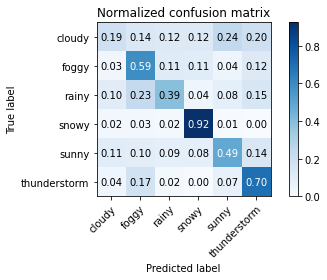

In [ ]:
plot_confusion_matrix(rnd_forest_cv_predictions, normalize=True)

### Logistic Regression model

In [ ]:
def logistic_regression_pipeline(dataframe: DataFrame,
                                 numerical_features: List[str],
                                 categorical_features: List[str],
                                 target_variable: str,
                                 features_col: str,
                                 with_std: bool = True,
                                 with_mean: bool = False,
                                 k_fold: int = 5) -> CrossValidatorModel:

    from pyspark.ml.classification import LogisticRegression
    from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
    from pyspark.ml.evaluation import MulticlassClassificationEvaluator
    from pyspark.ml.feature import IndexToString
    from pyspark.ml import Pipeline

    data_encoder = encoding_pipeline(dataframe,
                                     numerical_features,
                                     categorical_features,
                                     target_variable,
                                     with_std,
                                     with_mean)

    classifier = LogisticRegression(featuresCol=features_col, labelCol=LABEL_COL)

    predictions_idx_to_str = IndexToString(inputCol=PREDICTION_COL,
                                           outputCol=PREDICTED_TARGET_VARIABLE_COL,
                                           labels=data_encoder.stages[0].labels)

    stages = [data_encoder, classifier, predictions_idx_to_str]

    pipeline = Pipeline(stages=stages)

    # We use a ParamGridBuilder to construct a grid of parameters to search over.
    # With 3 values for regParam, 3 values for maxIter and 3 values for elasticNetParam,
    # this grid will have 3 x 3 x 3 = 12 parameter settings for CrossValidator to choose from.
    param_grid = ParamGridBuilder()\
        .addGrid(classifier.maxIter, [10, 100, 1000]) \
        .addGrid(classifier.regParam, [0.0, 0.05, 0.1]) \
        .addGrid(classifier.elasticNetParam, [0.0, 0.5, 1.0]) \
        .build()

    evaluator = MulticlassClassificationEvaluator(labelCol=LABEL_COL,
                                                  predictionCol=PREDICTION_COL,
                                                  metricName='accuracy')

    cross_val = CrossValidator(estimator=pipeline,
                               estimatorParamMaps=param_grid,
                               evaluator=evaluator,
                               numFolds=k_fold,
                               collectSubModels=True)

    cv_model = cross_val.fit(dataframe)

    return cv_model

In [ ]:
log_reg_cv_model = CrossValidatorModel.load(LOGISTIC_REGRESSION_CROSS_VALIDATION_MODEL_PATH) if LOAD_PRETRAINED_MODELS \
                   else logistic_regression_pipeline(train_df,
                                                     NUMERICAL_FEATURES,
                                                     CATEGORICAL_FEATURES,
                                                     TARGET_VARIABLE_COL,
                                                     FEATURES_COL)

In [ ]:
log_reg_cv_model_obj = log_reg_cv_model.bestModel.stages[-2]._java_obj

print('Best model according to k-fold cross validation:')
print(f' - regParam=[{log_reg_cv_model_obj.getRegParam()}]')
print(f' - elasticNetParam=[{log_reg_cv_model_obj.getElasticNetParam()}]')
print(f' - maxIter=[{log_reg_cv_model_obj.getMaxIter()}]')

Best model according to k-fold cross validation:
 - regParam=[0.0]
 - elasticNetParam=[0.0]
 - maxIter=[1000]

In [ ]:
if SAVE_COMPUTATIONS and not LOAD_PRETRAINED_MODELS:
    save_pyspark_model(log_reg_cv_model, LOGISTIC_REGRESSION_CROSS_VALIDATION_MODEL_PATH)

In [ ]:
log_reg_cv_predictions = log_reg_cv_model.transform(test_df)

In [ ]:
eval_predictions(log_reg_cv_predictions)

Accuracy: 0.47733809382128334
Precision: 0.44390801747900444
Recall: 0.47705055766795074
F1-score: 0.45988293720560103

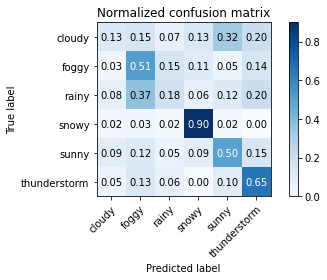

In [ ]:
plot_confusion_matrix(log_reg_cv_predictions, normalize=True)